# BigMart Sales Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Feature Description:

1. Numerical Features:
    - Item_Weight
    - Item_Visibility
    - Item_MRP
    - Outlet_Establishment_Year
    - Item_Outlet_Sales

2. Categorical Features:
    - Item_Identifier
    - Item_Fat_Content
    - Item_Type
    - Outlet_Identifier
    - Outlet_Size
    - Outlet_Location_Type
    - Outlet_Type
    

In [3]:
train.shape

(8523, 12)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### Handling Null values

In [5]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
train['Item_Weight'].mean()

np.float64(12.857645184135976)

In [7]:
percent = (train['Item_Weight'].isnull().sum() / len(train)) * 100

print(percent.round(2),"% rows are affected by missing values in Item_Weight column")

17.17 % rows are affected by missing values in Item_Weight column


In [8]:
percent = (train['Outlet_Size'].isnull().sum() / len(train)) * 100

print(percent.round(2),"% rows are affected by missing values in Outlet_Size column")

28.28 % rows are affected by missing values in Outlet_Size column


### 1. FillNA with Mean

In [9]:
# train['Item_Weight'].fillna(train['Item_Weight'].mean(), inplace=True)

### 2. KNN Imputer

In [10]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

outlet_size_map = {'Small': 0, 'Medium': 1, 'High': 2}

train["Outlet_Size_Code"] = train["Outlet_Size"].map(outlet_size_map)

features = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Size_Code']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(train[features])

imputer = KNNImputer(n_neighbors=5, weights = "distance")
imputed_scaled_data = imputer.fit_transform(scaled_data)

imputed_data = scaler.inverse_transform(imputed_scaled_data)

train[features] = imputed_data

train["Outlet_Size_Code"] = (
    train["Outlet_Size_Code"]
    .round()
    .clip(0, 2)
    .astype(int)
)

reverse_map = {
    0: "Small",
    1: "Medium",
    2: "High"
}

train["Outlet_Size"] = train["Outlet_Size_Code"].map(reverse_map)

# Remove the temporary encoded column
train.drop(columns=["Outlet_Size_Code"], inplace=True)

# Check remaining missing values
print(train[["Item_Weight", "Outlet_Size"]].isnull().sum())

Item_Weight    0
Outlet_Size    0
dtype: int64


## Data Visualization

In [11]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.893301,0.066132,140.992782,1997.831867,2181.288914
std,4.314740,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.300000,0.026989,93.826500,1987.000000,834.247400
50%,12.790985,0.053931,143.012800,1999.000000,1794.331000
75%,16.250000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


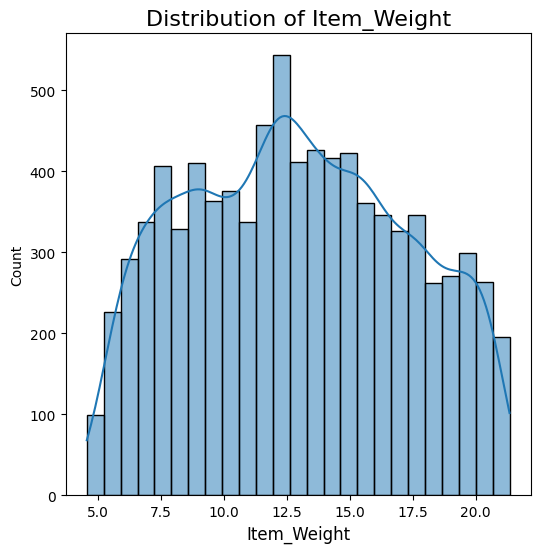

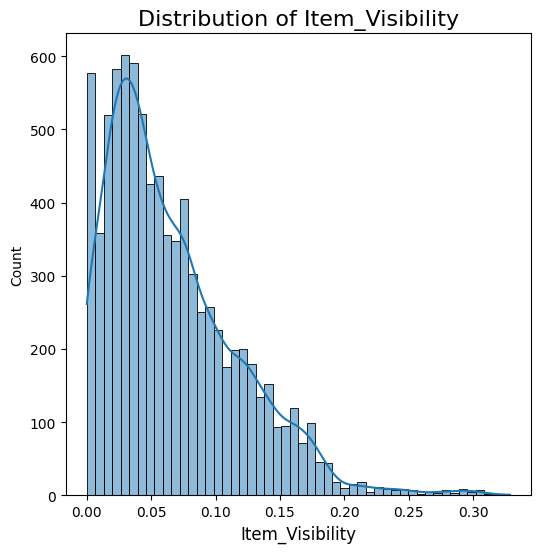

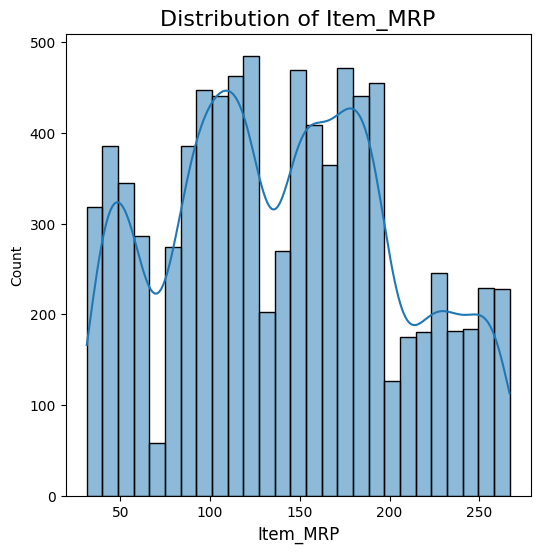

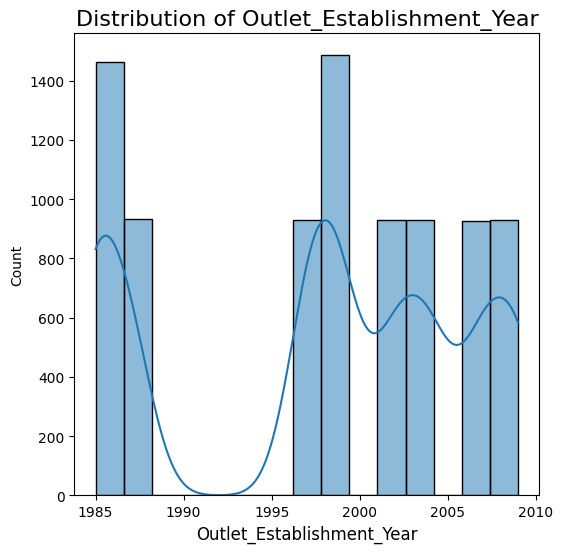

In [12]:
# Histplot

cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

for col in cols:
    plt.figure(figsize=(6,6))
    sns.histplot(data=train, x=col, kde=True, palette='viridis')
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(f'{col}', fontsize=12)
    plt.show()
    plt.close()

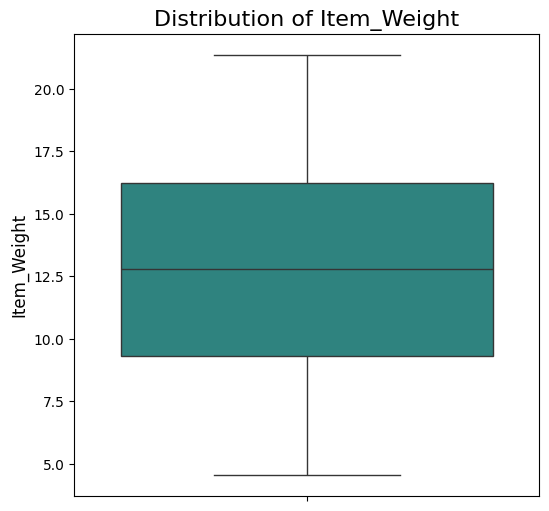

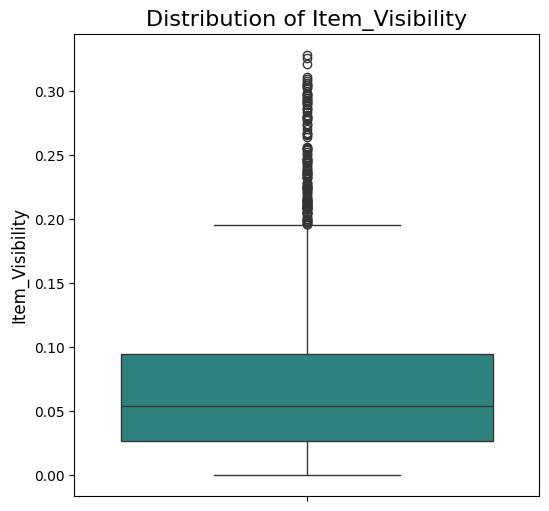

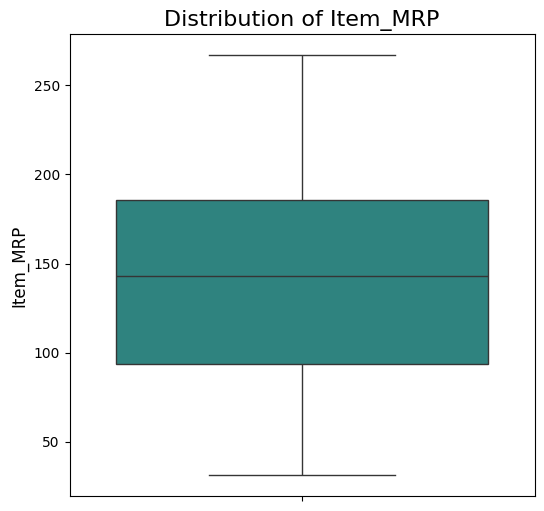

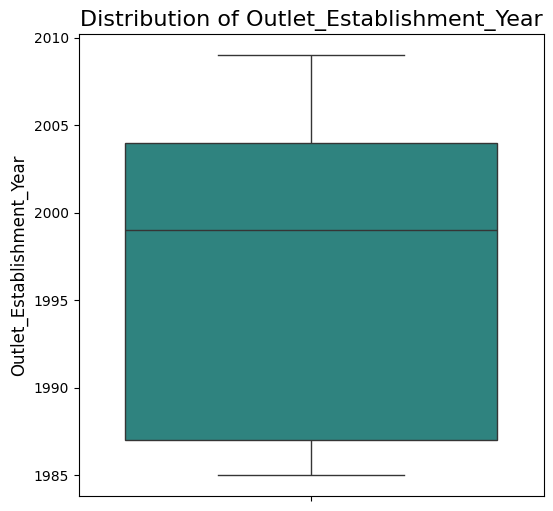

In [13]:
# Boxplot

cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']

for col in cols:
    plt.figure(figsize=(6,6))
    sns.boxplot(data=train, y=col, palette='viridis')
    plt.title(f'Distribution of {col}', fontsize=16)
    plt.ylabel(f'{col}', fontsize=12)
    plt.show()
    plt.close()

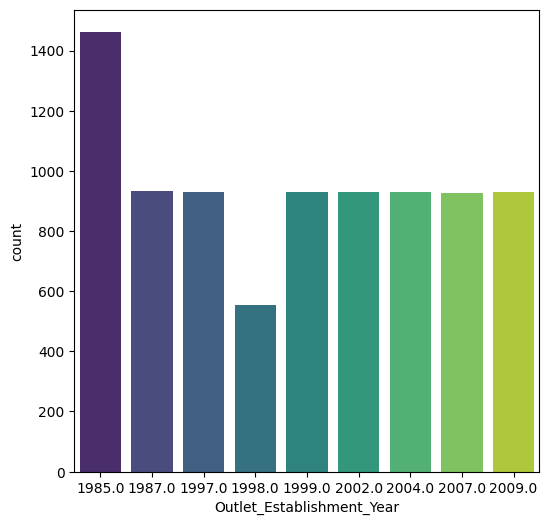

In [14]:
plt.figure(figsize=(6,6))
sns.countplot(data=train, x='Outlet_Establishment_Year', palette='viridis')
plt.show()

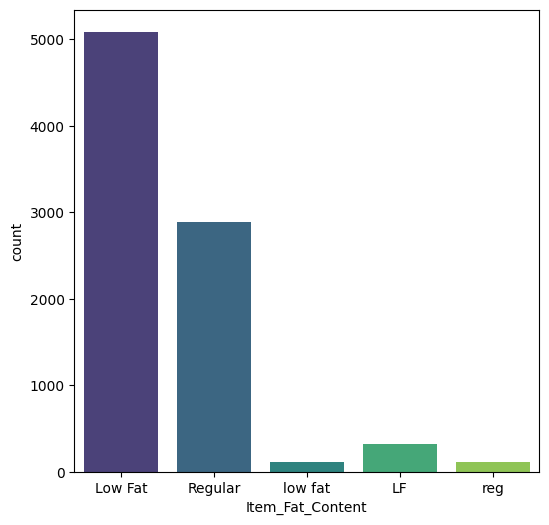

In [15]:
plt.figure(figsize=(6,6))
sns.countplot(data=train, x='Item_Fat_Content', palette='viridis')
plt.show()

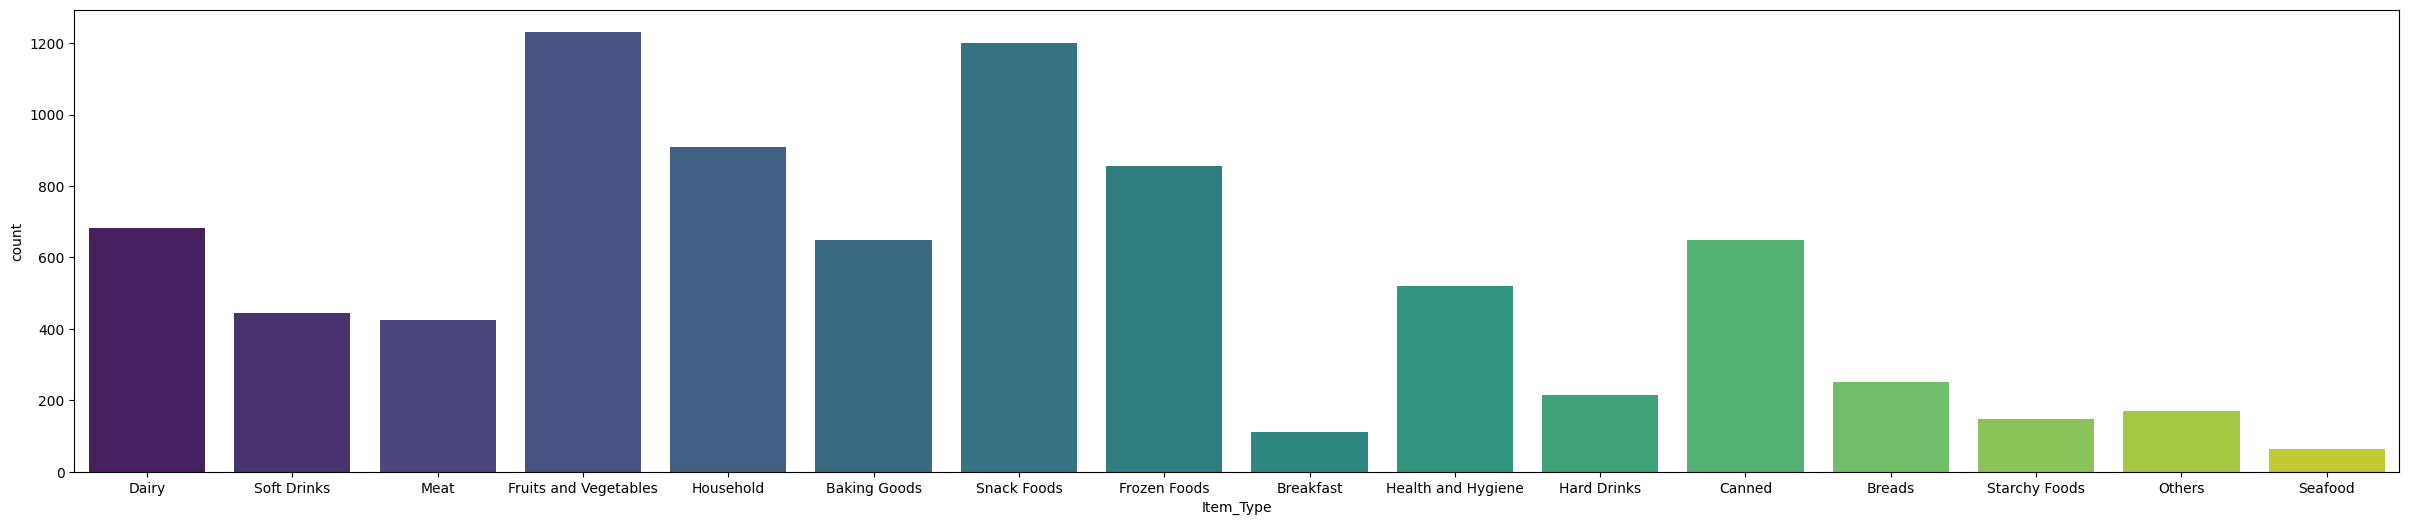

In [16]:
plt.figure(figsize=(30,6))
sns.countplot(data=train, x='Item_Type', palette='viridis')
plt.show()

## Data Preprocessing

In [17]:
train["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [18]:
# Low fat has 3 different representations

train["Item_Fat_Content"].replace({"LF": "Low Fat", "low fat": "Low Fat", "reg": "Regular"}, inplace=True)
train["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

### Split Features and Target

In [19]:
X = train.drop(columns='Item_Outlet_Sales', axis=1)
y = train['Item_Outlet_Sales']

## Train & Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_test.shape)

(1705, 11)


## Label Encoding

In [21]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    "Item_Identifier",
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Identifier",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
]

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test[categorical_cols] = encoder.transform(
    X_test[categorical_cols]
)

In [22]:
X_test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
7503,487.0,14.300000,0.0,0.026300,5.0,79.4302,1.0,1987.0,0.0,2.0,1.0
2957,1388.0,7.930000,0.0,0.071136,8.0,42.7086,8.0,1997.0,2.0,0.0,1.0
7031,244.0,14.500000,1.0,0.041313,3.0,42.0454,9.0,1999.0,1.0,0.0,1.0
1084,14.0,17.670625,1.0,0.044767,14.0,173.7054,5.0,1985.0,1.0,2.0,3.0
856,887.0,10.195000,1.0,0.012456,10.0,197.5110,6.0,2004.0,2.0,1.0,1.0


## Model Training

In [26]:
# XGBoost Regressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

regressor = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42,
    n_jobs=4
)

regressor.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Training data Evaluation

In [27]:
prediction = regressor.predict(X_train)

print(f"Mean Absolute Error: {mean_absolute_error(y_train, prediction)}")
print(f"Mean Squared Error: {mean_squared_error(y_train, prediction)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_train, prediction))}")

r2_train = metrics.r2_score(y_train, prediction)
print(f"R2 Score: {r2_train}")

Mean Absolute Error: 702.5982171179282
Mean Squared Error: 974693.771809017
Root Mean Squared Error: 987.2658060568173
R2 Score: 0.6704945169689951


### Test Data Evaluation

In [28]:
prediction_test = regressor.predict(X_test)

print(f"Mean Absolute Error: {mean_absolute_error(y_test, prediction_test)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, prediction_test)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, prediction_test))}")

r2_test = metrics.r2_score(y_test, prediction_test)
print(f"R2 Score: {r2_test}")

Mean Absolute Error: 722.3344943528498
Mean Squared Error: 1062432.7836223238
Root Mean Squared Error: 1030.74380115639
R2 Score: 0.6091079895722251


In [29]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse = cross_val_score(
    regressor,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_mse)

print("RMSE for each fold:", np.round(cv_rmse, 2))
print(f"Mean CV RMSE: {cv_rmse.mean():.2f}")
print(f"CV RMSE standard deviation: {cv_rmse.std():.2f}")

RMSE for each fold: [1128.63 1082.53 1117.65 1099.4  1134.06]
Mean CV RMSE: 1112.45
CV RMSE standard deviation: 19.09


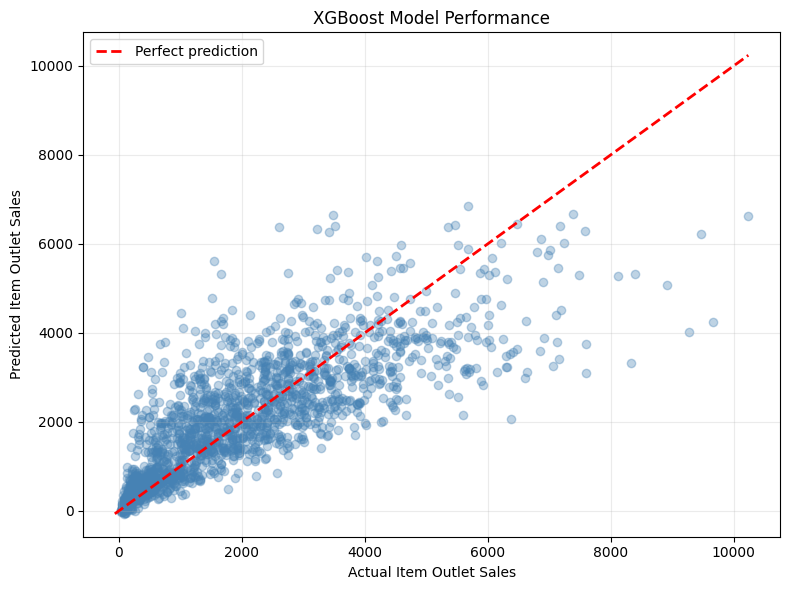

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, prediction_test, alpha=0.35, color="steelblue")

lower_bound = min(y_test.min(), prediction_test.min())
upper_bound = max(y_test.max(), prediction_test.max())
plt.plot(
    [lower_bound, upper_bound],
    [lower_bound, upper_bound],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Item Outlet Sales")
plt.ylabel("Predicted Item Outlet Sales")
plt.title("XGBoost Model Performance")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print(mean_absolute_error(y_test, baseline_predictions))
print(np.sqrt(mean_squared_error(y_test, baseline_predictions)))

1321.738728500184
1651.989750472933
